# Financial Forecasting Frontier: Distributed Machine Learning

## Data Parallelism in Banking Analytics using Apache Spark

### Project Objective

Demonstrate how Apache Spark utilizes data parallelism to efficiently process large-scale banking datasets and support scalable machine learning workflows.

### Project Goal

The goal of this notebook is to explore partitioning strategies, parallel aggregations, distributed machine learning, resource monitoring, and task scheduling using Spark's distributed architecture.

### Technologies Used

* Apache Spark
* PySpark
* Spark MLlib
* Python
* Google Colab
* Matplotlib
* psutil

### Business Context

Modern banks generate large volumes of customer and transaction data. Data parallelism enables faster processing and analysis by distributing workloads across multiple partitions, improving scalability and computational efficiency.

### GitHub Repository

GitHub Link: [Link](https://github.com/Aks18had/Financial-Forecasting-Frontier-Distributed-ML)

### Dataset Source

Dataset provided by Alma Better


In [ ]:
from google.colab import drive # Mounting GDrive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pyspark -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psutil

In [ ]:
from pyspark.sql import SparkSession # Creating the spark session here

spark = SparkSession.builder \
    .appName("Banking_Data_Parallelism") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Distributed_ML_Project/bank.csv" # Giving data path from my Gdrive

spark_df = spark.read.csv(
    DATA_PATH,
    header=True,
    inferSchema=True
)

print("Dataset Loaded Successfully")
print("Shape:", (spark_df.count(), len(spark_df.columns)))

spark_df.show(5)

Dataset Loaded Successfully
Shape: (4521, 17)
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no| 

## Question 1: Data Preparation and Partitioning

### Objective

Load the banking dataset and apply partitioning techniques to improve parallel processing efficiency in Apache Spark.

In [ ]:
print(
    "Current Partitions:",
    spark_df.rdd.getNumPartitions()
)

Current Partitions: 1


In [ ]:
partitioned_df = spark_df.repartition(
    4,
    "job"
)

print(
    "Partitions After Repartition:",
    partitioned_df.rdd.getNumPartitions()
)

Partitions After Repartition: 4


In [ ]:
print("Rows:", partitioned_df.count())
print("Columns:", len(partitioned_df.columns))

Rows: 4521
Columns: 17


In [ ]:
partitioned_df.groupBy(
    "job"
).count().show()

+-------------+-----+
|          job|count|
+-------------+-----+
|   unemployed|  128|
|     services|  417|
|      student|   84|
|      unknown|   38|
|   management|  969|
|  blue-collar|  946|
|self-employed|  183|
|       admin.|  478|
|   technician|  768|
|    housemaid|  112|
| entrepreneur|  168|
|      retired|  230|
+-------------+-----+



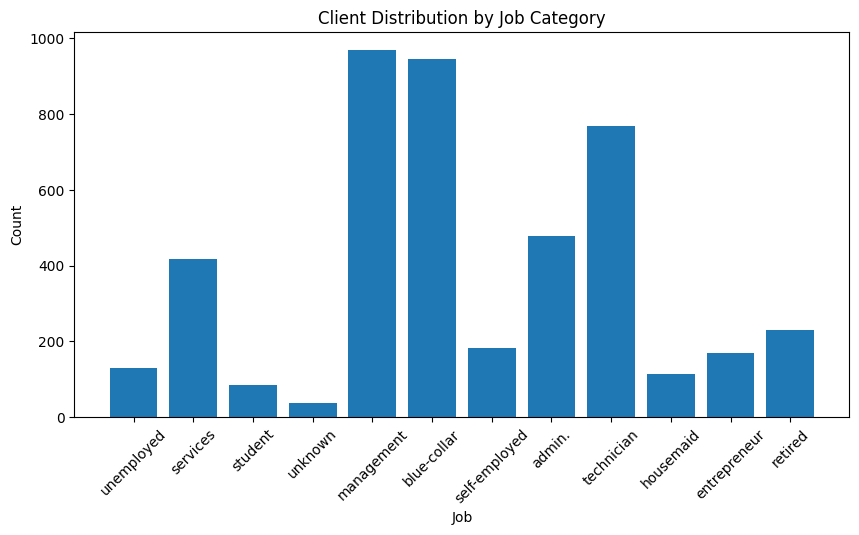

In [ ]:
job_counts = ( # A bar chart has been used for displaying the Partition by Job
    partitioned_df
    .groupBy("job")
    .count()
    .toPandas()
)

plt.figure(figsize=(10,5))

plt.bar(
    job_counts["job"],
    job_counts["count"]
)

plt.title("Client Distribution by Job Category")
plt.xlabel("Job")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

The dataset was repartitioned using the **job** column to improve parallel processing. Partitioning distributes data across multiple executors, enabling faster aggregation and analysis operations.

## Question 2: Parallel Data Analysis

### Objective

Perform distributed aggregations using Apache Spark to analyze customer financial behavior and loan patterns.

In [ ]:
from pyspark.sql.functions import avg # Alias feature is used from SQL here to show Apache spark aggregations

avg_balance_job = (
    partitioned_df
    .groupBy("job")
    .agg(
        avg("balance").alias("average_balance")
    )
)

avg_balance_job.show()

+-------------+------------------+
|          job|   average_balance|
+-------------+------------------+
|   unemployed|       1089.421875|
|     services|1103.9568345323742|
|      student|1543.8214285714287|
|      unknown|1501.7105263157894|
|   management|1766.9287925696594|
|  blue-collar| 1085.161733615222|
|self-employed|1392.4098360655737|
|       admin.|  1226.73640167364|
|   technician|     1330.99609375|
|    housemaid|2083.8035714285716|
| entrepreneur|          1645.125|
|      retired| 2319.191304347826|
+-------------+------------------+



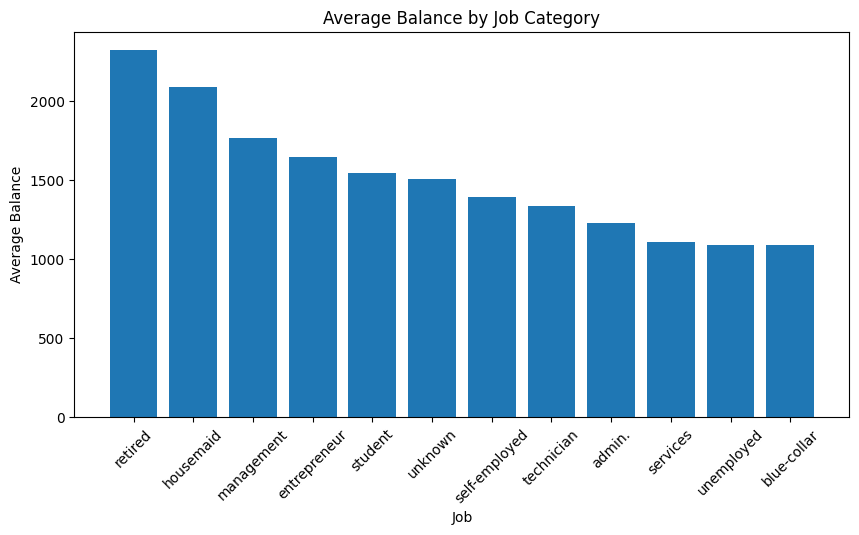

In [ ]:
avg_balance_pd = ( # A bar chart has been used for displaying the Partition by Job
    avg_balance_job
    .toPandas()
    .sort_values(
        "average_balance",
        ascending=False
    )
)

plt.figure(figsize=(10,5))

plt.bar(
    avg_balance_pd["job"],
    avg_balance_pd["average_balance"]
)

plt.title("Average Balance by Job Category")
plt.xlabel("Job")
plt.ylabel("Average Balance")

plt.xticks(rotation=45)

plt.show()

### Observation

Spark executed the aggregation in parallel across partitions. The results show that account balances vary significantly across different job categories.

In [ ]:
from pyspark.sql.functions import when

age_group_df = partitioned_df.withColumn(
    "age_group",
    when(partitioned_df.age < 30, "<30")
    .when(partitioned_df.age <= 39, "30-39")
    .when(partitioned_df.age <= 49, "40-49")
    .when(partitioned_df.age <= 59, "50-59")
    .otherwise("60+")
)

In [ ]:
loan_age_group = ( # For Loan Analysis
    age_group_df
    .filter(age_group_df.loan == "yes")
    .groupBy("age_group")
    .count()
)

loan_age_group.show()

+---------+-----+
|age_group|count|
+---------+-----+
|    30-39|  271|
|    40-49|  184|
|      <30|   68|
|    50-59|  160|
|      60+|    8|
+---------+-----+



In [ ]:
top_age_groups = loan_age_group.orderBy( # Top 5 Age Groups
    "count",
    ascending=False
)

top_age_groups.show(10)

+---------+-----+
|age_group|count|
+---------+-----+
|    30-39|  271|
|    40-49|  184|
|    50-59|  160|
|      <30|   68|
|      60+|    8|
+---------+-----+



In [ ]:
print(
    "Partitions Used:",
    partitioned_df.rdd.getNumPartitions()
)

Partitions Used: 4


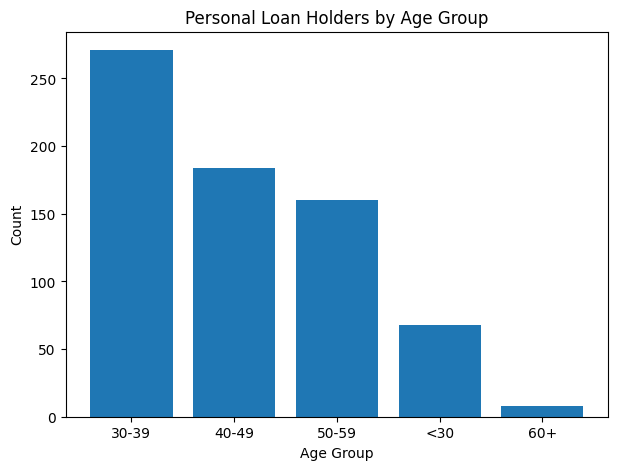

In [ ]:
loan_pd = ( # Count of Age Groups who opted for Loans
    top_age_groups
    .toPandas()
)

plt.figure(figsize=(7,5))

plt.bar(
    loan_pd["age_group"],
    loan_pd["count"]
)

plt.title("Personal Loan Holders by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

### Observation

The **30–39 age group** had the highest number of personal loan holders (**271 customers**). This indicates that middle-aged customers are more likely to utilize personal loan products and may represent an important segment for banking services and risk assessment.

## Question 3: Model Training with Parallelism

### Objective

Train a Logistic Regression model using Spark ML and demonstrate distributed machine learning through data parallelism.

In [ ]:
from pyspark.ml.feature import StringIndexer

categorical_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
    "y"
]

indexed_df = partitioned_df

for col_name in categorical_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_indexed"
    )

    indexed_df = indexer.fit(
        indexed_df
    ).transform(
        indexed_df
    )

In [ ]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "job_indexed",
    "marital_indexed",
    "education_indexed",
    "default_indexed",
    "housing_indexed",
    "loan_indexed",
    "contact_indexed",
    "month_indexed",
    "poutcome_indexed"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

model_df = assembler.transform(
    indexed_df
)

In [ ]:
final_df = model_df.select( # basic train test split 8:2
    "features",
    "y_indexed"
)

train_df, test_df = final_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Records:", train_df.count())
print("Testing Records:", test_df.count())

Training Records: 3655
Testing Records: 866


### Distributed Logistic Regression Training

Apache Spark distributes data across partitions and performs model training in parallel, reducing processing time for large-scale datasets.

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="y_indexed"
)

lr_model = lr.fit(
    train_df
)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [ ]:
predictions = lr_model.transform(
    test_df
)

predictions.select(
    "prediction",
    "y_indexed",
    "probability"
).show(10, truncate=False)

+----------+---------+-----------------------------------------+
|prediction|y_indexed|probability                              |
+----------+---------+-----------------------------------------+
|0.0       |0.0      |[0.9280716127926169,0.07192838720738315] |
|0.0       |0.0      |[0.9263461750679454,0.07365382493205463] |
|0.0       |0.0      |[0.9830949330513252,0.016905066948674774]|
|0.0       |0.0      |[0.9836575771556426,0.016342422844357385]|
|0.0       |0.0      |[0.9876802914560612,0.012319708543938823]|
|0.0       |0.0      |[0.9161124903045942,0.08388750969540582] |
|0.0       |0.0      |[0.9743100360959681,0.025689963904031887]|
|0.0       |0.0      |[0.9725920777188604,0.02740792228113964] |
|0.0       |0.0      |[0.8854441315681411,0.11455586843185894] |
|0.0       |0.0      |[0.9876778895887177,0.012322110411282283]|
+----------+---------+-----------------------------------------+
only showing top 10 rows


In [ ]:
print(
    "Training Partitions:",
    train_df.rdd.getNumPartitions()
)

print(
    "Testing Partitions:",
    test_df.rdd.getNumPartitions()
)

Training Partitions: 4
Testing Partitions: 4


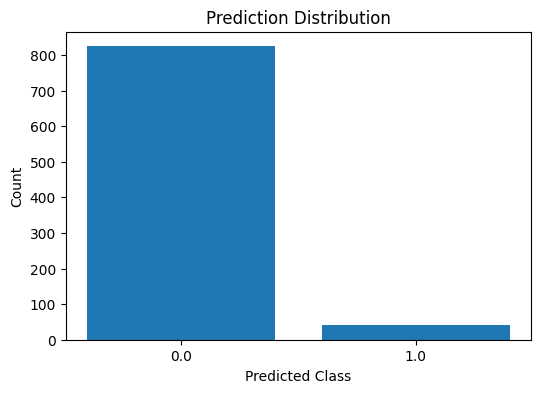

In [ ]:
prediction_dist = (
    predictions
    .groupBy("prediction")
    .count()
    .toPandas()
)

plt.figure(figsize=(6,4))

plt.bar(
    prediction_dist["prediction"].astype(str),
    prediction_dist["count"]
)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")

plt.show()

In [ ]:
predictions.groupBy(
    "prediction"
).count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|  824|
|       1.0|   42|
+----------+-----+



### Observation

The Logistic Regression model was trained using Spark's distributed ML framework. Training and prediction tasks were executed across multiple partitions, demonstrating the effectiveness of data parallelism for scalable machine learning.

## Question 4: Model Evaluation

### Objective

Evaluate the performance of the Logistic Regression model trained using distributed data processing.

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="y_indexed",
    predictionCol="prediction"
)

accuracy = evaluator.evaluate(
    predictions,
    {evaluator.metricName: "accuracy"}
)

precision = evaluator.evaluate(
    predictions,
    {evaluator.metricName: "weightedPrecision"}
)

recall = evaluator.evaluate(
    predictions,
    {evaluator.metricName: "weightedRecall"}
)

f1_score = evaluator.evaluate(
    predictions,
    {evaluator.metricName: "f1"}
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1_score)

Accuracy : 0.8983833718244804
Precision: 0.8793993886260529
Recall   : 0.8983833718244804
F1 Score : 0.8798472733180916


In [ ]:
evaluation_df = pd.DataFrame({ # Evaluation result table is dispalyed here
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1_score
    ]
})

evaluation_df

,Metric,Score
0,Accuracy,0.898383
1,Precision,0.879399
2,Recall,0.898383
3,F1 Score,0.879847


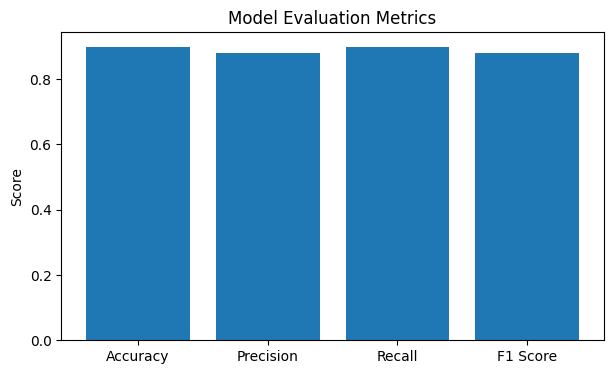

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(
    evaluation_df["Metric"],
    evaluation_df["Score"]
)

plt.title("Model Evaluation Metrics")
plt.ylabel("Score")

plt.show()

### Observation

The distributed Logistic Regression model achieved **89.84% Accuracy** and **87.98% F1 Score**. These results demonstrate that Spark's parallel processing framework can efficiently train machine learning models while maintaining strong predictive performance.

## Question 5: Resource Monitoring

### Objective

Monitor CPU and memory utilization during Spark processing to understand resource consumption in distributed workflows.

In [ ]:
import psutil

cpu_usage = psutil.cpu_percent()

memory_usage = psutil.virtual_memory().percent

print(f"CPU Usage: {cpu_usage}%")
print(f"Memory Usage: {memory_usage}%")

CPU Usage: 20.8%
Memory Usage: 18.8%


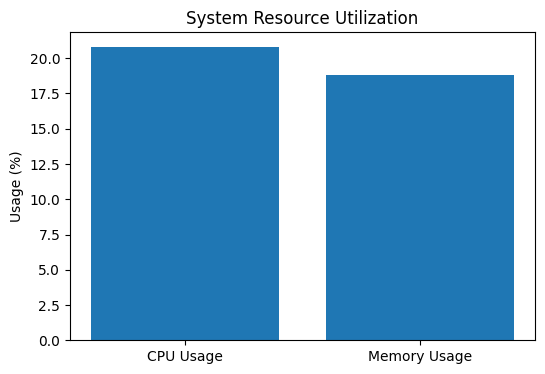

In [ ]:
resource_df = pd.DataFrame({
    "Resource": [
        "CPU Usage",
        "Memory Usage"
    ],
    "Percentage": [
        cpu_usage,
        memory_usage
    ]
})

plt.figure(figsize=(6,4))

plt.bar(
    resource_df["Resource"],
    resource_df["Percentage"]
)

plt.title("System Resource Utilization")
plt.ylabel("Usage (%)")

plt.show()

### Observation

Resource monitoring showed **20.8% CPU usage** and **18.8% memory usage** during execution. The results indicate efficient utilization of system resources while processing data across multiple Spark partitions.

## Question 6: Task Management and Scheduling

### Objective

Understand how Apache Spark manages tasks, schedules jobs, and optimizes distributed execution through DAG scheduling and lazy evaluation.

In [ ]:
avg_balance_job.explain(True) # Spark DAG (Directed Acyclic Graph) execution

== Parsed Logical Plan ==
'Aggregate ['job], ['job, 'avg('balance) AS average_balance#232]
+- RepartitionByExpression [job#18], 4
   +- Relation [age#17,job#18,marital#19,education#20,default#21,balance#22,housing#23,loan#24,contact#25,day#26,month#27,duration#28,campaign#29,pdays#30,previous#31,poutcome#32,y#33] csv

== Analyzed Logical Plan ==
job: string, average_balance: double
Aggregate [job#18], [job#18, avg(balance#22) AS average_balance#232]
+- RepartitionByExpression [job#18], 4
   +- Relation [age#17,job#18,marital#19,education#20,default#21,balance#22,housing#23,loan#24,contact#25,day#26,month#27,duration#28,campaign#29,pdays#30,previous#31,poutcome#32,y#33] csv

== Optimized Logical Plan ==
Aggregate [job#18], [job#18, avg(balance#22) AS average_balance#232]
+- RepartitionByExpression [job#18], 4
   +- Project [job#18, balance#22]
      +- Relation [age#17,job#18,marital#19,education#20,default#21,balance#22,housing#23,loan#24,contact#25,day#26,month#27,duration#28,campaign

In [ ]:
print("Training Partitions:", train_df.rdd.getNumPartitions())
print("Testing Partitions:", test_df.rdd.getNumPartitions())

Training Partitions: 4
Testing Partitions: 4


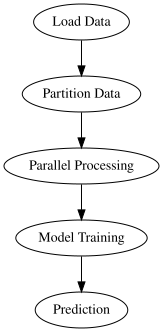

In [ ]:
from graphviz import Digraph # Using the Graphviz for work flow

flow = Digraph()

flow.node("A", "Load Data")
flow.node("B", "Partition Data")
flow.node("C", "Parallel Processing")
flow.node("D", "Model Training")
flow.node("E", "Prediction")

flow.edge("A", "B")
flow.edge("B", "C")
flow.edge("C", "D")
flow.edge("D", "E")

flow

### Observation

Spark manages execution using a **DAG (Directed Acyclic Graph) Scheduler** and **lazy evaluation**. Tasks are executed only when an action is triggered, allowing Spark to optimize execution plans and improve parallel processing efficiency.


---



# Key Findings

- Repartitioning distributed the dataset across **4 partitions** for parallel processing.
- The **30–39 age group** had the highest number of personal loan holders.
- Spark successfully performed distributed aggregations and machine learning tasks.
- Logistic Regression achieved **89.84% Accuracy** and **87.98% F1 Score**.
- Resource monitoring showed efficient CPU and memory utilization during execution.
- Spark's DAG Scheduler and lazy evaluation optimized task execution.

# Learnings

- Learned how Spark partitions data for parallel processing.
- Applied distributed aggregations and parallel analytics.
- Trained machine learning models using Spark ML.
- Monitored system resource utilization during distributed execution.
- Understood Spark's DAG Scheduler and lazy evaluation mechanisms.
- Gained practical experience with scalable banking data analytics.

# Conclusion

This project demonstrated how Apache Spark leverages **data parallelism to process banking datasets efficiently**. Through **partitioning, distributed aggregations, machine learning, resource monitoring, and task scheduling,** Spark provided scalable and high-performance analytics. The results highlight the importance of distributed computing techniques in modern banking and financial systems.